In [1]:
import numpy as np
import pandas as pd
train = pd.read_csv("../data/raw/train_FD004.txt", sep=r"\s+", header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [2]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
train.columns = columns
train.head(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [3]:
train.nunique()

engine_id      249
cycle          543
setting_1      536
setting_2      105
setting_3        2
sensor_1         6
sensor_2      1704
sensor_3     13558
sensor_4     17353
sensor_5         6
sensor_6        46
sensor_7      5926
sensor_8      1038
sensor_9     25297
sensor_10       21
sensor_11      737
sensor_12     5627
sensor_13      483
sensor_14    15938
sensor_15    11915
sensor_16        2
sensor_17       54
sensor_18        6
sensor_19        2
sensor_20      652
sensor_21    21574
dtype: int64

looks like all the sensors are having most of unique values

In [4]:
usefull_sensors = ['setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

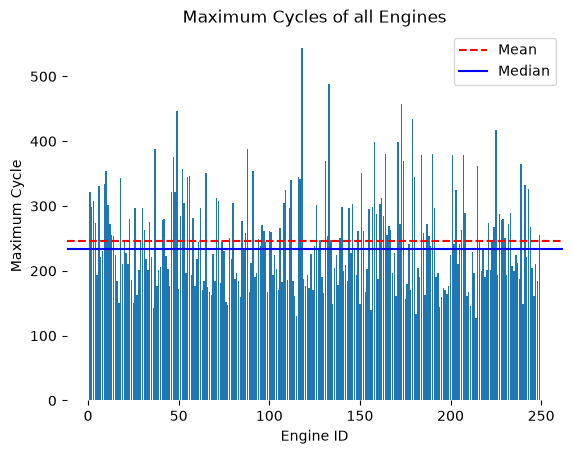

In [5]:
import matplotlib.pyplot as plt
max_cycles = train.groupby("engine_id")["cycle"].max()
plt.bar(max_cycles.index, max_cycles.values)
plt.xlabel("Engine ID")
plt.ylabel("Maximum Cycle")
plt.title("Maximum Cycles of all Engines")
plt.axhline(y=max_cycles.mean(), color="r", linestyle="--", label="Mean")
plt.axhline(y=max_cycles.median(), color="b", linestyle="-", label="Median")
legend = plt.legend()
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

In [6]:
train["rul"] = train["engine_id"].map(max_cycles) - train["cycle"]

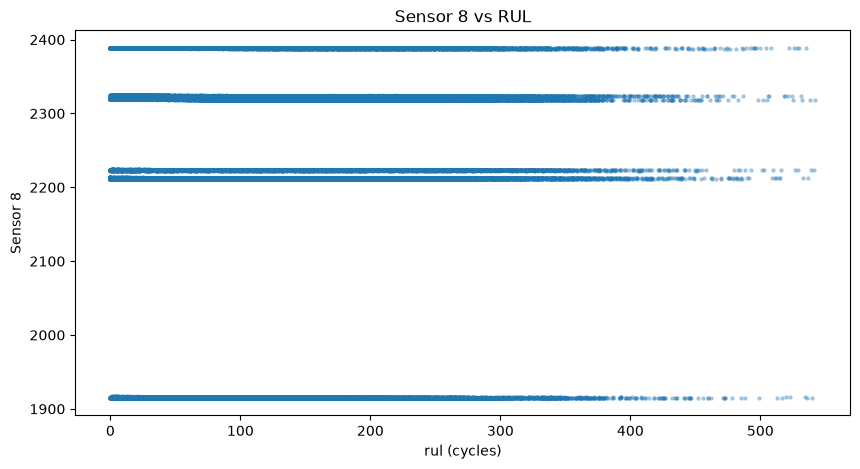

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_8"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 8")
plt.title("Sensor 8 vs RUL")
plt.show()

looks like sensor is having different value according to one of 6 conditions

In [8]:
from sklearn.model_selection import train_test_split
engine_ids = train["engine_id"].unique()
train_engines, val_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)
print("Training Engines:",len(train_engines))
print("Validation Engines:",len(val_engines))

Training Engines: 199
Validation Engines: 50


In [9]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  49294
validation rows:  11955


In [10]:
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["rul"]

X_val = val_data[feature_col]
Y_val = val_data["rul"]

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))


baseline MAE:  43.412300292764535
baseline RMSE:  60.67587497713488


its our baseline model with high error now we will try to reduce it as much as possible

<Axes: >

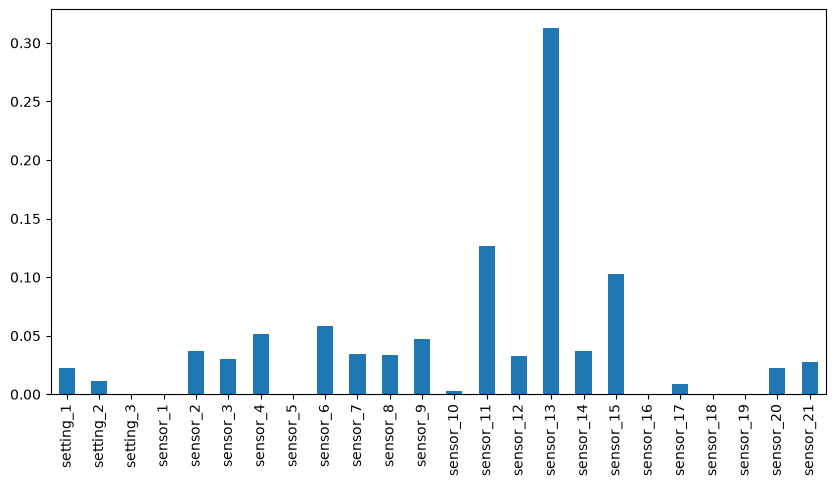

In [12]:
feature_importance = pd.Series(baseline_model.feature_importances_, index=feature_col)#.sort_values(ascending=False)
feature_importance.plot(kind="bar", figsize=(10, 5))

looks like setting 3 sensor 1,5,16,18,19 does not have much to do with prediction 
lets first verify using premutation imporatnce method

In [13]:
from sklearn.inspection import permutation_importance
prem_importance = permutation_importance(baseline_model, X_val, Y_val, n_repeats=15, random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error")
prem_importance_df = pd.DataFrame({
    "sensor": feature_col,
    "importance": prem_importance.importances_mean,
    "importance_std": prem_importance.importances_std
})
prem_importance_df

,sensor,importance,importance_std
0,setting_1,0.379120,0.029022
1,setting_2,0.147882,0.025299
2,setting_3,-0.000003,0.000002
3,sensor_1,0.000906,0.000341
4,sensor_2,2.318299,0.086354
5,sensor_3,1.082088,0.077618
6,sensor_4,4.515652,0.141159
7,sensor_5,0.000471,0.000387
8,sensor_6,8.333880,0.213701
9,sensor_7,1.547826,0.053458


only setting 3 and sensor 19 dosent have much importance lets drop them but before droping setting 3 lets first try to identify 6 conditions and classify sensor values according to it and also lets first try rul capped 

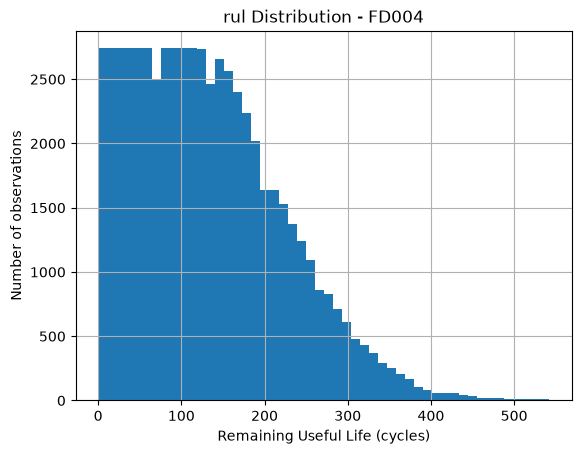

In [14]:
train["rul"].hist(bins=50)
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Number of observations")
plt.title("rul Distribution - FD004")
plt.show()

In [15]:
(train["rul"] > 150).sum()

np.int64(23751)

In [16]:
train["RUL_capped"] = train["rul"].clip(upper=150)

In [23]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["RUL_capped"]
X_val = val_data[feature_col]
Y_val = val_data["RUL_capped"]

In [18]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  19.599135089920537
baseline RMSE:  26.171587368656724


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
settings_train_scaled = scaler.fit_transform(train[["setting_1","setting_2","setting_3"]])
train["condition"] = kmeans.fit_predict(settings_train_scaled)
settings_val_scaled = scaler.transform(val_data[["setting_1","setting_2","setting_3"]])
val_data["condition"] = kmeans.predict(settings_val_scaled)

In [20]:
stats = train.groupby("condition")[usefull_sensors].agg(["mean", "std"])

In [21]:
def normalize_by_condition(df, stats, cols):
    df = df.copy()
    for col in cols:
        mean = df["condition"].map(stats[(col, "mean")])
        std = df["condition"].map(stats[(col, "std")])
        std = std.replace(0, 1)  # avoid division by zero
        df[col] = (df[col] - mean) / std
    return df

In [24]:
train_norm = normalize_by_condition(train_data, stats, usefull_sensors)
val_norm   = normalize_by_condition(val_data, stats, usefull_sensors)

sometimes above code shows error so try rerun the cell 22

In [25]:
feature_col = usefull_sensors
X_train = train_norm[feature_col]
Y_train = train_norm["RUL_capped"]

X_val = val_norm[feature_col]
Y_val = val_norm["RUL_capped"]

In [26]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  19.48210539523212
baseline RMSE:  25.996549891897008


lets try rolling window

In [27]:
train_norm = train_norm.sort_values(["engine_id", "cycle"])
val_norm   = val_norm.sort_values(["engine_id", "cycle"])

In [28]:
window = 5

for col in usefull_sensors:
    train_norm[f"{col}_rmean"] = (
        train_norm.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    train_norm[f"{col}_rstd"] = (
        train_norm.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(window, min_periods=1).std())
    )

    val_norm[f"{col}_rmean"] = (
        val_norm.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    val_norm[f"{col}_rstd"] = (
        val_norm.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(window, min_periods=1).std())
    )

rstd_cols = [f"{col}_rstd" for col in usefull_sensors]
train_norm[rstd_cols] = train_norm[rstd_cols].fillna(0)
val_norm[rstd_cols] = val_norm[rstd_cols].fillna(0)

In [29]:
rolling_cols = [f"{col}_rmean" for col in usefull_sensors] + [f"{col}_rstd" for col in usefull_sensors]
feature_col = usefull_sensors + rolling_cols

X_train2 = train_norm[feature_col]
Y_train2 = train_norm["RUL_capped"]
X_val2 = val_norm[feature_col]
Y_val2 = val_norm["RUL_capped"]

baseline_model3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model3.fit(X_train2, Y_train2)
y_pred2 = baseline_model3.predict(X_val2)
print("baseline3 MAE: ", mean_absolute_error(Y_val2, y_pred2))
print("baseline3 RMSE: ", np.sqrt(mean_squared_error(Y_val2, y_pred2)))

baseline3 MAE:  19.055093266415728
baseline3 RMSE:  25.75474153045825


lets try different models


In [30]:
from xgboost import XGBRegressor
import numpy as np

modelx = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
modelx.fit(X_train, Y_train)

# Predict
predictions = modelx.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 18.94368553161621
RMSE: 25.587299582065


In [31]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

modell = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# Train
modell.fit(
    X_train, Y_train,
    eval_set=[(X_val, Y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30)]
)

# Predict
predictions = modell.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)


Training until validation scores don't improve for 30 rounds


e:\software\predictive-maintenance\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[204]	valid_0's l1: 18.9732	valid_0's l2: 653.856
MAE : 18.97315542642074
RMSE: 25.570606622491933


so we got our best model XGBRegressor with:
MAE : 18.94368553161621
RMSE: 25.587299582065

In [32]:
test = pd.read_csv("../data/raw/test_FD004.txt", sep=r"\s+", header=None)

In [33]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
test.columns = columns
test.head(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,...,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,...,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,...,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,...,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,...,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326


In [34]:
settings_test_scaled = scaler.transform(test[["setting_1", "setting_2", "setting_3"]])
test["condition"] = kmeans.predict(settings_test_scaled)

In [35]:
test_norm = normalize_by_condition(test, stats, usefull_sensors)
X_test = test_norm[usefull_sensors]
test_norm["pred_rul"] = modelx.predict(X_test)
last_preds = test_norm.groupby("engine_id").last()["pred_rul"]
true_rul = pd.read_csv("../data/raw/RUL_FD004.txt", sep=r"\s+", header=None, names=["true_rul"])
true_rul.index = true_rul.index + 1  # engine_id starts at 1, not 0
true_rul_capped = true_rul["true_rul"].clip(upper=150)
mae = mean_absolute_error(true_rul_capped, last_preds)
rmse = np.sqrt(mean_squared_error(true_rul_capped, last_preds))
print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 19.090299606323242
Test RMSE: 25.097596364228163


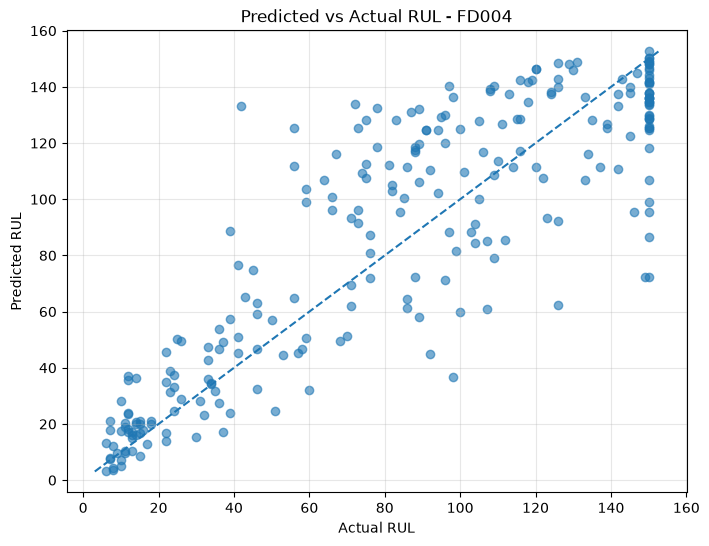

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(true_rul_capped, last_preds, alpha=0.6)

min_val = min(true_rul_capped.min(), last_preds.min())
max_val = max(true_rul_capped.max(), last_preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL - FD004")

plt.grid(True, alpha=0.3)
plt.show()